#### Importing Python Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
import string
from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import download

pd.set_option("display.max_columns",None)
pd.set_option("display.max_colwidth",200)

download('punkt')
download('stopwords')

sns.set(style="whitegrid",context="notebook")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samsa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samsa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Loading the Dataset

In [2]:
df = pd.read_csv("../Dataset/Tweet Dataset.csv",encoding="ISO-8859-1",names=["Target","ID","Date","Flag","User","Text"])
df.head()

,Target,ID,Date,Flag,User,Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [3]:
df['Target'] = df['Target'].replace(4, 1)
df['Target'].value_counts()

Target
0    800000
1    800000
Name: count, dtype: int64

#### Shape, Columns and Rows of the Dataset

In [4]:
print(f"Shape of the Dataset : {df.shape}")
print(f"Columns of the Dataset : {df.shape[1]}")
print(f"Rows of the Dataset : {df.shape[0]}")

Shape of the Dataset : (1600000, 6)
Columns of the Dataset : 6
Rows of the Dataset : 1600000


#### Columns List of the Dataset

In [5]:
print("Columns of the Dataset :")
print(df.columns)

Columns of the Dataset :
Index(['Target', 'ID', 'Date', 'Flag', 'User', 'Text'], dtype='object')


#### Datatypes of the Dataset

In [6]:
print("Data Types of the Dataset :")
df.dtypes

Data Types of the Dataset :


Target     int64
ID         int64
Date      object
Flag      object
User      object
Text      object
dtype: object

#### Memory Usage of the Dataset

In [7]:
df.memory_usage(deep=True)

Index           132
Target     12800000
ID         12800000
Date      123200000
Flag       91200000
User       94659633
Text      197176786
dtype: int64

#### Complete Information of the Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   Target  1600000 non-null  int64 
 1   ID      1600000 non-null  int64 
 2   Date    1600000 non-null  object
 3   Flag    1600000 non-null  object
 4   User    1600000 non-null  object
 5   Text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


#### Complete Description of the Dataset

In [9]:
df.describe()

,Target,ID
count,1600000.0,1.600000e+06
mean,0.5,1.998818e+09
std,0.5,1.935761e+08
min,0.0,1.467810e+09
25%,0.0,1.956916e+09
50%,0.5,2.002102e+09
75%,1.0,2.177059e+09
max,1.0,2.329206e+09


#### Missing Values Analysis

In [10]:
print(f"Count of the Missing Values : \n{df.isnull().sum()}")

Count of the Missing Values : 
Target    0
ID        0
Date      0
Flag      0
User      0
Text      0
dtype: int64


In [11]:
print(f"Percentage of the Missing Values : {(df.isnull().sum()/len(df))*100}%")

Percentage of the Missing Values : Target    0.0
ID        0.0
Date      0.0
Flag      0.0
User      0.0
Text      0.0
dtype: float64%


In [12]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(0).astype(int).astype(str) + "%"
})

missing_summary

,Missing_Count,Missing_Percentage
Target,0,0%
ID,0,0%
Date,0,0%
Flag,0,0%
User,0,0%
Text,0,0%


#### Duplicated Analysis

In [13]:
duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Duplicate Rows",
        "Duplicate Rows based on Text"
    ],
    "Count": [
        df.duplicated().sum(),
        df[df.duplicated(subset=["Text"], keep=False)].shape[0]
    ]
})

duplicate_summary


,Metric,Count
0,Total Duplicate Rows,0
1,Duplicate Rows based on Text,26968


#### Target Variable (Sentiment) Analysis

In [14]:
print("Sentiment Distribution :")
df["Target"].value_counts()

Sentiment Distribution :


Target
0    800000
1    800000
Name: count, dtype: int64

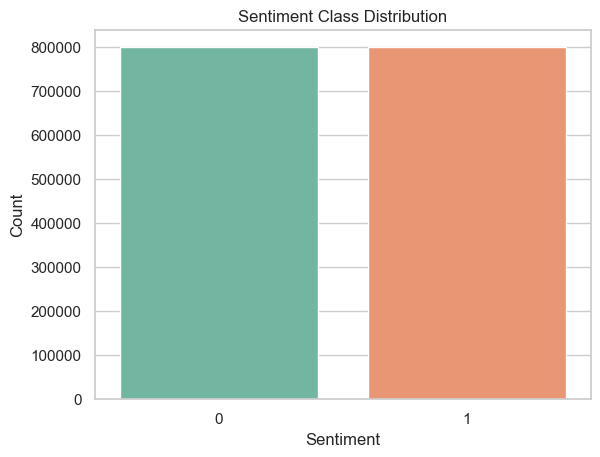

In [15]:
sns.countplot(
    x="Target",
    hue="Target",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

#### Date Time Analysis

###### Date Parsing

In [16]:
df['Date'] = df['Date'].str.replace(r'\s[A-Z]{3}$', '', regex=True)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'].isnull().sum()

np.int64(0)

###### Time-Based Features

In [17]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Hour"] = df["Date"].dt.hour

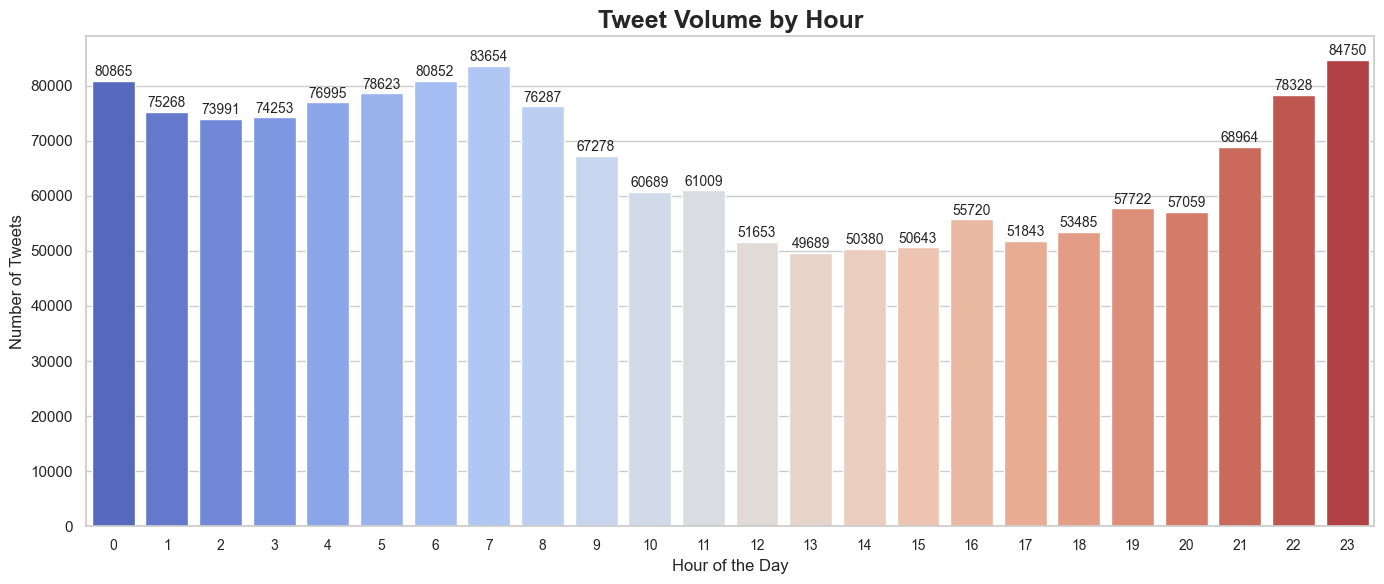

In [18]:
# Calculate tweet count per hour
hour_counts = df.groupby("Hour").size().reset_index(name="Count")

plt.figure(figsize=(14,6))
sns.set_style("whitegrid")

# Create barplot with vibrant palette
colors = sns.color_palette("coolwarm", len(hour_counts))
sns.barplot(
    x="Hour",
    y="Count",
    data=hour_counts,
    palette=colors
)

# Title and axis labels
plt.title("Tweet Volume by Hour", fontsize=18, weight="bold")
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.xticks(fontsize=10)

# Add value labels on top of bars
for index, row in hour_counts.iterrows():
    plt.text(
        index,
        row['Count'] + max(hour_counts['Count'])*0.01,  # slight offset above bar
        row['Count'],
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### User Analysis

###### Unique Users

In [19]:
print(f"Count of Unique Users : {df["User"].nunique()}")

Count of Unique Users : 659775


###### Number of Active Users

In [20]:
top_users = df["User"].value_counts().head(20)
top_users

User
lost_dog           549
webwoke            345
tweetpet           310
SallytheShizzle    281
VioletsCRUK        279
mcraddictal        276
tsarnick           248
what_bugs_u        246
Karen230683        238
DarkPiano          236
SongoftheOss       227
Jayme1988          225
keza34             219
ramdomthoughts     216
shanajaca          213
wowlew             212
nuttychris         211
TraceyHewins       211
thisgoeshere       207
Spidersamm         205
Name: count, dtype: int64

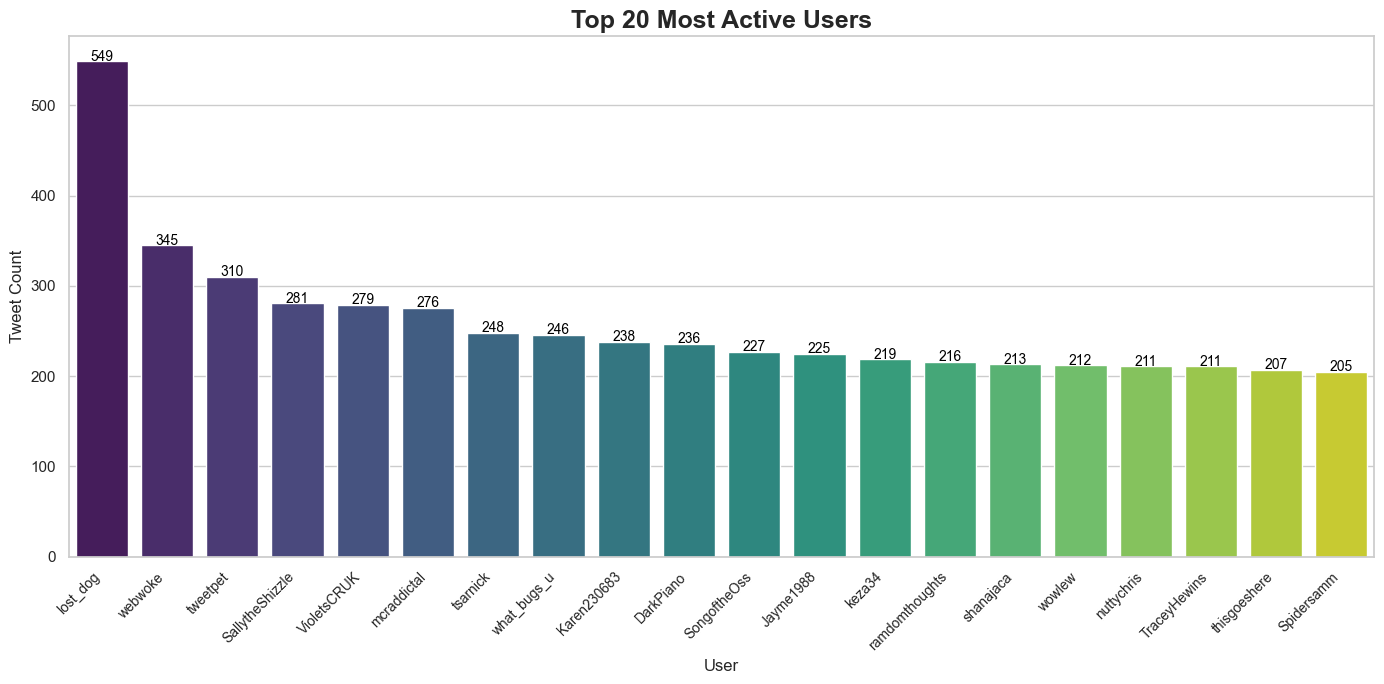

In [21]:
# Reset index and rename columns
top_users_df = df['User'].value_counts().head(20).reset_index()
top_users_df.columns = ['User', 'Tweet_Count']

plt.figure(figsize=(14,7))
sns.set_style("whitegrid")

# Barplot with gradient color
colors = sns.color_palette("viridis", len(top_users_df))
sns.barplot(
    x="User",
    y="Tweet_Count",
    data=top_users_df,
    palette=colors
)

# Title and labels
plt.title("Top 20 Most Active Users", fontsize=18, weight="bold")
plt.xlabel("User", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add value labels on top of bars
for index, row in top_users_df.iterrows():
    plt.text(
        index,
        row['Tweet_Count'] + 0.5,
        row['Tweet_Count'],
        color='black',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### Text Length Analysis

###### Character Length

In [22]:
df["Char_Length"] = df["Text"].astype(str).apply(len)

In [23]:
df["Char_Length"].describe()

count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: Char_Length, dtype: float64

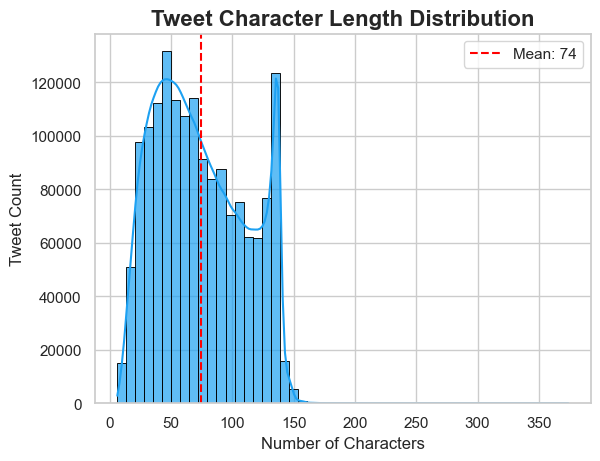

In [24]:
sns.histplot(
    df["Char_Length"],
    bins=50,
    kde=True,
    color="#1DA1F2",
    alpha=0.7,
    edgecolor="black"
)

plt.title("Tweet Character Length Distribution", fontsize=16, weight="bold")
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)

# Add mean line
mean_length = df["Char_Length"].mean()
plt.axvline(mean_length, color="red", linestyle="--", label=f"Mean: {int(mean_length)}")
plt.legend()

plt.show()

###### Word Count

In [25]:
df["Word_Count"] = df["Text"].astype(str).apply(lambda x: len(x.split()))
df["Word_Count"]

0          19
1          21
2          18
3          10
4          21
           ..
1599995    11
1599996    11
1599997    11
1599998    12
1599999     5
Name: Word_Count, Length: 1600000, dtype: int64

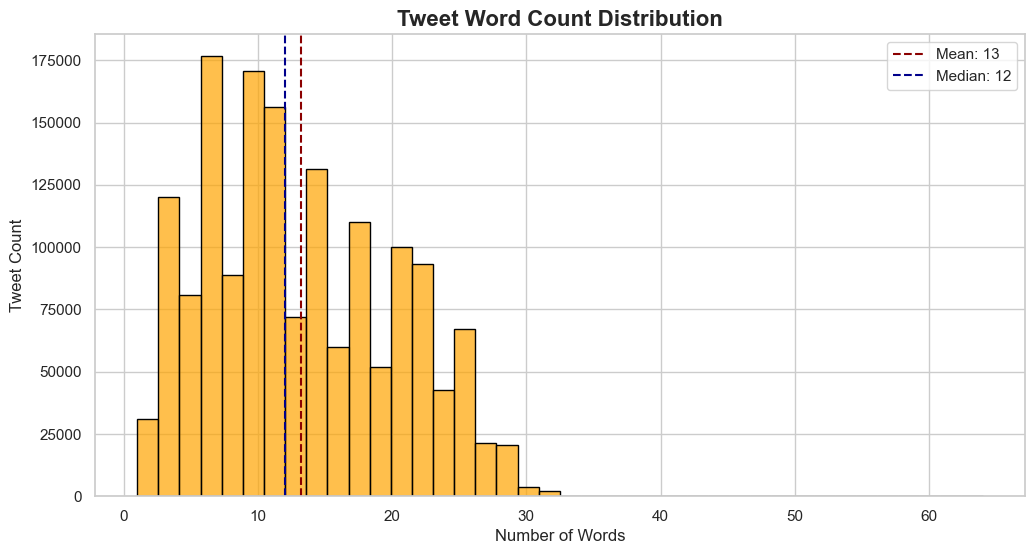

In [26]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

# Histogram with KDE, color, transparency, and edge color
sns.histplot(
    df["Word_Count"],
    bins=40,
    color="orange",
    alpha=0.7,
    edgecolor="black"
)

# Title and labels
plt.title("Tweet Word Count Distribution", fontsize=16, weight="bold")
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)

# Add mean and median lines
mean_count = df["Word_Count"].mean()
median_count = df["Word_Count"].median()

plt.axvline(mean_count, color="darkred", linestyle="--", label=f"Mean: {int(mean_count)}")
plt.axvline(median_count, color="darkblue", linestyle="--", label=f"Median: {int(median_count)}")
plt.legend()

plt.show()

#### Sentiment vs Length Analysis

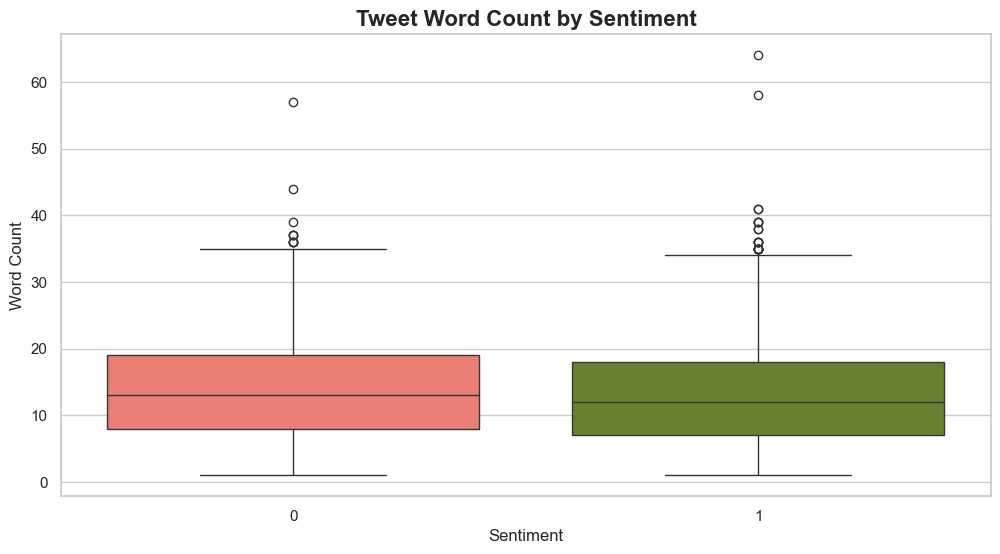

In [27]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x="Target", 
    y="Word_Count",  # make sure column name is lowercase
    data=df,
    palette={'0': "#FF6F61", '1': "#6B8E23"}
)
plt.title("Tweet Word Count by Sentiment", fontsize=16, weight="bold")
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Word Count", fontsize=12)
plt.show()

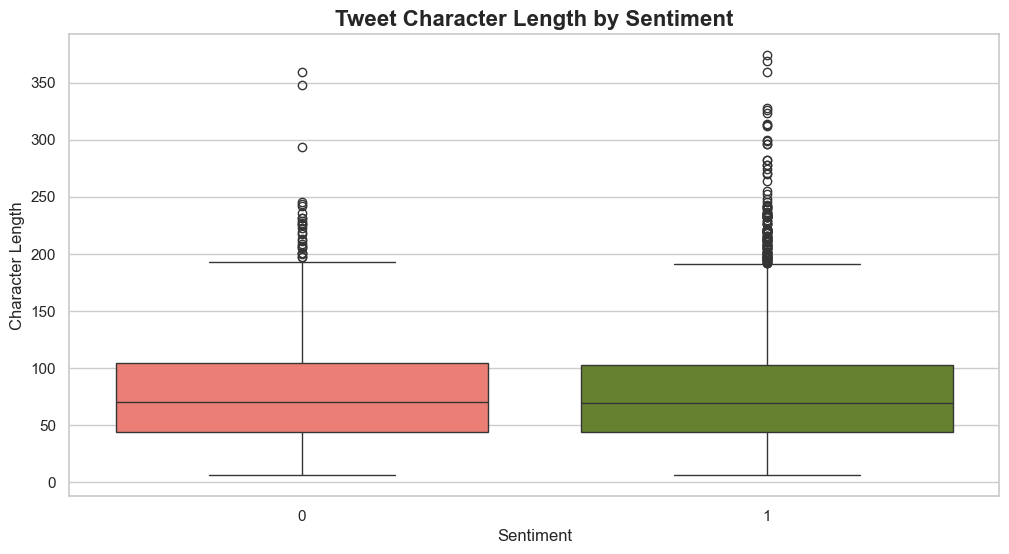

In [28]:
# Character Length by Sentiment
plt.figure(figsize=(12,6))
sns.boxplot(
    x="Target", 
    y="Char_Length", 
    data=df,
    palette={'0': "#FF6F61", '1': "#6B8E23"}
)
plt.title("Tweet Character Length by Sentiment", fontsize=16, weight="bold")
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Character Length", fontsize=12)
plt.show()

#### URL, Mention and Hashtag Analysis

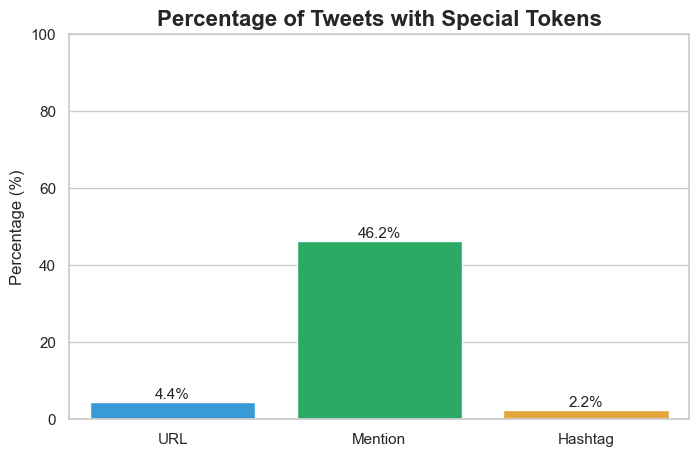

In [29]:
# Create features
df["Has_URL"] = df["Text"].str.contains(r"http[s]?://", regex=True)
df["Has_Mention"] = df["Text"].str.contains(r"@\w+", regex=True)
df["Has_Hashtag"] = df["Text"].str.contains(r"#\w+", regex=True)

# Calculate percentages
percentages = [
    df["Has_URL"].mean() * 100,
    df["Has_Mention"].mean() * 100,
    df["Has_Hashtag"].mean() * 100
]

# Plot
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

sns.barplot(
    x=["URL", "Mention", "Hashtag"],
    y=percentages,
    palette=["#1DA1F2", "#17BF63", "#FFAD1F"]  # Twitter-like colors
)

# Title and labels
plt.title("Percentage of Tweets with Special Tokens", fontsize=16, weight="bold")
plt.ylabel("Percentage (%)", fontsize=12)
plt.ylim(0, 100)

# Add value labels on top of bars
for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

plt.show()

#### Text Cleaning for Liguistuc EDA

In [30]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

df["Tokens"] = df["Text"].astype(str).apply(clean_text)
df["Tokens"]

0                                     [awww, thats, bummer, shoulda, got, david, carr, third, day]
1          [upset, cant, update, facebook, texting, might, cry, result, school, today, also, blah]
2                                      [dived, many, times, ball, managed, save, rest, go, bounds]
3                                                          [whole, body, feels, itchy, like, fire]
4                                                                   [behaving, im, mad, cant, see]
                                                    ...                                           
1599995                                                        [woke, school, best, feeling, ever]
1599996                                             [thewdbcom, cool, hear, old, walt, interviews]
1599997                                                      [ready, mojo, makeover, ask, details]
1599998                                   [happy, birthday, boo, alll, time, tupac, amaru, shakur]
1599999   

#### Vocabulary and Token Statistics

###### Vocabulary Size

In [31]:
vocabulary = Counter()
df["Tokens"] .apply(vocabulary.update)
len(vocabulary)

406521

###### Most Common Words

In [32]:
common_words = vocabulary.most_common(20)
common_words

[('im', 177520),
 ('good', 89397),
 ('day', 82920),
 ('get', 81487),
 ('like', 77749),
 ('go', 72908),
 ('got', 69686),
 ('dont', 66930),
 ('today', 64609),
 ('going', 64090),
 ('love', 63457),
 ('work', 62763),
 ('cant', 62601),
 ('time', 56107),
 ('back', 55979),
 ('lol', 55183),
 ('u', 52819),
 ('one', 52191),
 ('know', 51198),
 ('really', 49554)]

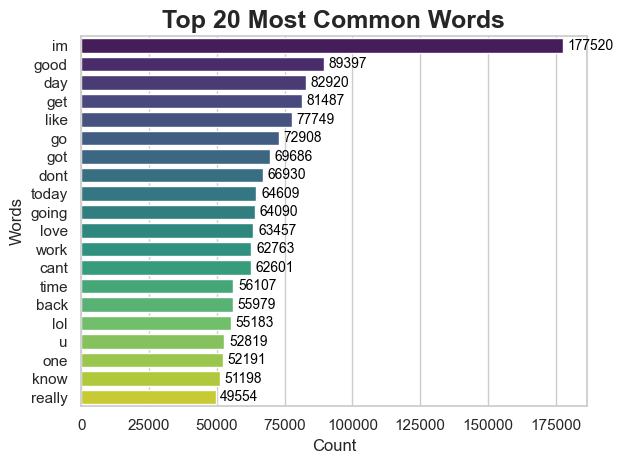

In [33]:
words, counts = zip(*common_words)

# Create horizontal barplot with gradient color
colors = sns.color_palette("viridis", len(words))
sns.barplot(x=list(counts), y=list(words), palette=colors)

# Title and labels
plt.title("Top 20 Most Common Words", fontsize=18, weight="bold")
plt.xlabel("Count", fontsize=12)
plt.ylabel("Words", fontsize=12)

# Add value labels on bars
for i, v in enumerate(counts):
    plt.text(v + max(counts)*0.01, i, str(v), color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Sentiment-Specific Word Analysis

In [34]:
positive_words = Counter()
negative_words = Counter()

df[df["Target"] == 1]["Tokens"].apply(positive_words.update)
df[df["Target"] == 0]["Tokens"].apply(negative_words.update)

structured_words = pd.DataFrame({
    "Positive_Word": [w for w, c in positive_words.most_common(10)],
    "Positive_Count": [c for w, c in positive_words.most_common(10)],
    "Negative_Word": [w for w, c in negative_words.most_common(10)],
    "Negative_Count": [c for w, c in negative_words.most_common(10)]
})

structured_words

,Positive_Word,Positive_Count,Negative_Word,Negative_Count
0,im,74875,im,102645
1,good,60846,get,45317
2,love,46834,go,45125
3,day,44835,dont,44917
4,like,37109,work,44001
5,get,36170,cant,43592
6,thanks,33743,like,40640
7,lol,33492,got,38090
8,got,31596,day,38085
9,going,30647,today,36196


#### Tweet Length vs Time

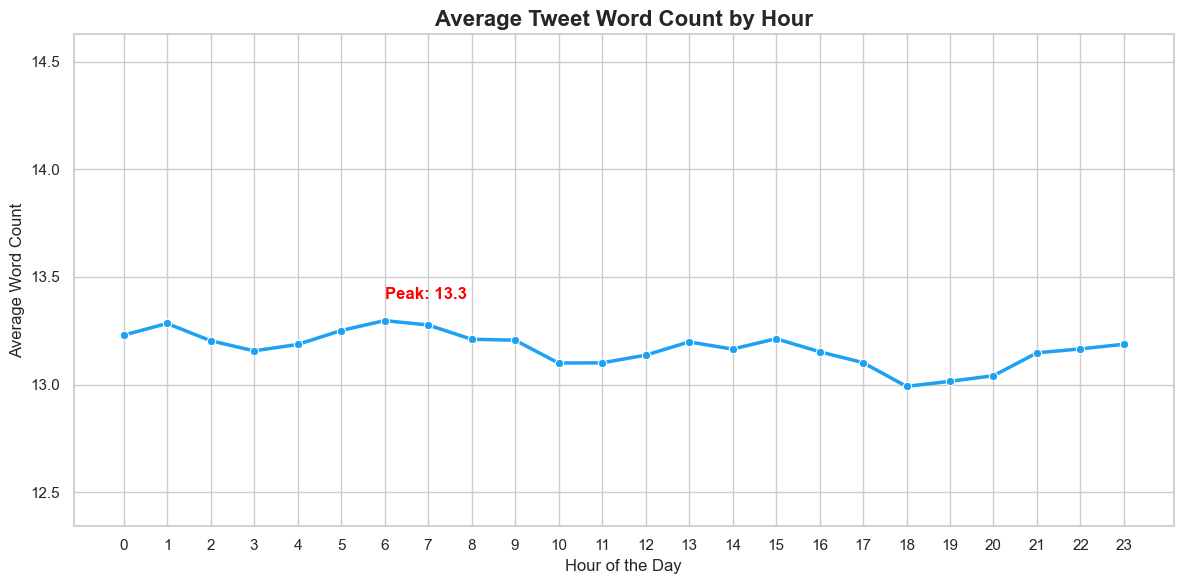

In [35]:
# Aggregate average word count by hour
hourly_avg = df.groupby("Hour")["Word_Count"].mean().reset_index()  # lowercase

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

# Line plot with markers
sns.lineplot(
    x="Hour",
    y="Word_Count",
    data=hourly_avg,
    marker="o",
    color="#1DA1F2",
    linewidth=2.5
)

# Title and labels
plt.title("Average Tweet Word Count by Hour", fontsize=16, weight="bold")
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Average Word Count", fontsize=12)
plt.xticks(range(0,24))

# Annotate peak hour
peak_hour = hourly_avg.loc[hourly_avg["Word_Count"].idxmax()]
plt.ylim(hourly_avg["Word_Count"].min() * 0.95, hourly_avg["Word_Count"].max() * 1.1)

plt.text(
    peak_hour["Hour"], 
    peak_hour["Word_Count"] + 0.1,  # smaller offset
    f'Peak: {peak_hour["Word_Count"]:.1f}', 
    color="red", 
    weight="bold"
)

plt.tight_layout()
plt.show()

#### Outlier Detection

In [36]:
df[df["Word_Count"] > 50][["Text", "Word_Count"]].head()

,Text,Word_Count
770356,I'm so boreeeeed. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .I need internet.,57
1079511,? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? twitterart,58
1080011,? ? ? ? ? ? ? ?? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?Take that,64


In [37]:
df[df["Char_Length"] > 200][["Text", "Char_Length"]].head()


,Text,Char_Length
248973,"Ð?ÑÑ, OpenOffice Ð²ÑÐ±ÐµÑ?Ð¸Ð» Ñ?Ð²Ð¾ÐµÐ¹ Ð½ÐµÑ?ÑÐ°Ð±Ð¸Ð»ÑÐ½Ð¾Ñ?ÑÑÑ Ð¿ÑÐ¸ ÑÐ°Ð±Ð¾ÑÐµ Ñ? ÑÐ°Ð±Ð»Ð¸ÑÐ°Ð¼Ð¸, Ð²ÑÐµÐ¼ÐµÐ½Ð½Ð¾ Ð¿ÐµÑÐµÐµÐ·Ð¶Ð°Ñ Ð¾Ð±ÑÐ°ÑÐ½Ð¾ Ð½Ð° M$. Ð§ÑÐ²Ñ?ÑÐ²ÑÑ ...",226
305242,"èªª åé«éå¾ç¬¬ä¸å (LOL),æ²æ³å°è?¸å®³é²æ²»æ³å¯¦è¡å¾,ä¸?ç¥é?æéº¼æ¨£,æä¹å?å¸¸å»çåäº (annoyed),å°å?¦ä¸ééè²¼èå ¨é?¢ç¦?è?¸,å?¯æ¯ä¸é²å»å?æ¯ä¸å ç å³ http://...",213
322655,"Ð¾Ð±Ð¸Ð´Ð½Ð¾ ÑÑÐ¾ Ð¼Ð½Ð¾Ð³Ð¸Ðµ ÑÐ²Ð¸ÑÐµÑÑ?Ð½Ðµ Ð½Ðµ Ð·Ð°Ð¼ÐµÑÐ°ÑÑ ÐºÐ¾Ð³Ð´Ð° Ð¸Ð¼ Ð¾ÑÐ¿ÑÐ°Ð²Ð»Ñ?ÐµÑÑ reply, Ð° direct Ð¼Ð¾Ð¶Ð½Ð¾ Ð¾ÑÐ¿ÑÐ°Ð²Ð»Ñ?ÑÑ ÑÐ¾Ð»ÑÐºÐ¾ ÑÐµÐ¼ ÐºÑÐ¾ ÑÐµÐ±Ñ...",211
324570,"ÐÐºÐ°Ð·Ð°Ð»Ð¾Ñ?Ñ, ÑÑÐ¾ Ð¿ÑÐµÑ?Ñ?-ÐºÐ¾Ð½ÑÐµÑÐµÐ½ÑÐ¸Ñ? SONY Ð² Home Ð¿Ð¾Ñ?Ð²Ð¸ÑÑ?Ñ? ÑÐµÑÐµÐ· Ð½ÐµÑ?ÐºÐ¾Ð»ÑÐºÐ¾ ÑÐ°Ñ?Ð¾Ð² Ð¿Ð¾Ñ?Ð»Ðµ Ð¿ÑÐµÑ?Ñ?-ÐºÐ¾Ð½ÑÐµÑÐµÐ½ÑÐ¸Ð¸ Ð¡Ð¼Ð¾ÑÑÑ ÑÐµÑ...",227
325649,"@Arwy Ð´Ð¸Ñ?Ðº Ð½Ðµ Ð¿ÑÐ¾Ð²ÐµÑÑ?Ð», Ð½Ðµ Ð·Ð½Ð°Ñ. Ð?Ð¾ Ð¿Ð¾ÐºÐ°Ð·Ð°Ð»Ð¾Ñ?Ñ, ÑÑÐ¾ backup Ð°Ð¹ÑÐ¾Ð½Ð° Ð¾Ð¿Ñ?ÑÑ Ð´ÐµÐ»Ð°ÐµÑÑ?Ñ? Ð´Ð¾Ð»Ð³Ð¾ Ð² Ð¿ÑÐ¾ÑÐ»Ð¾Ð¹ Ð²ÐµÑÑ?Ð¸Ð¸ Ð²ÑÐ¾Ð´Ðµ Ð¿Ð¾Ð¿Ñ...",236


#### Correlation Analysis

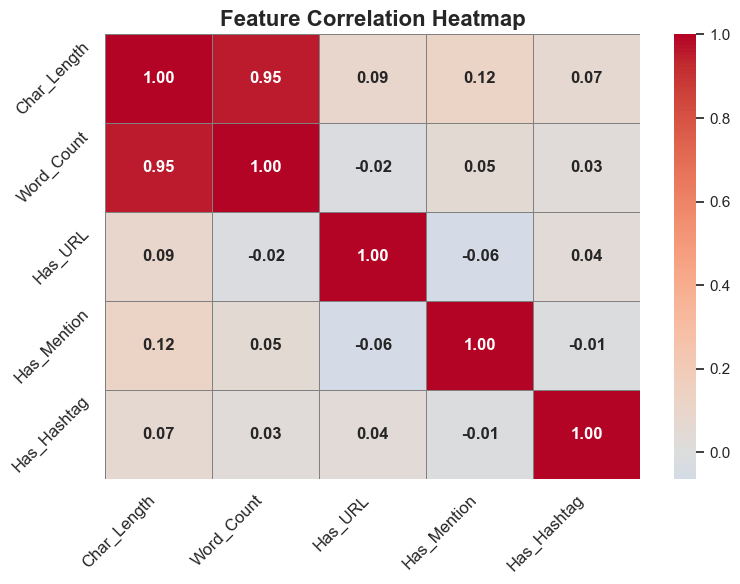

In [38]:
numeric_cols = ["Char_Length", "Word_Count", "Has_URL", "Has_Mention", "Has_Hashtag"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.set_style("white")

sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f",           # 2 decimals for clarity
    cmap="coolwarm", 
    center=0,            # center colormap at 0
    annot_kws={"size":12, "weight":"bold"},
    linewidths=0.5,      # gridlines between cells
    linecolor="gray"
)

plt.title("Feature Correlation Heatmap", fontsize=16, weight="bold")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12,rotation=45)
plt.tight_layout()
plt.show()